## 实验2：MLP 与激活函数挑战

### 任务一


### 0. 环境与数据加载


In [1]:
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

num_inputs, num_outputs, num_hiddens = 784, 10, 256


### 1. 激活函数


In [2]:
def relu(X):
    return torch.maximum(X, torch.zeros_like(X))


def sigmoid(X):
    return 1 / (1 + torch.exp(-X))


def tanh(X):
    return torch.tanh(X)


def leaky_relu(X, alpha=0.01):
    return torch.where(X > 0, X, alpha * X)


def elu(X, alpha=1.0):
    return torch.where(X > 0, X, alpha * (torch.exp(X) - 1))


### 2. 模型实现


In [3]:
def init_params(device='cpu'):
    W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), device=device, requires_grad=True)
    b1 = torch.zeros(num_hiddens, device=device, requires_grad=True)
    W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), device=device, requires_grad=True)
    b2 = torch.zeros(num_outputs, device=device, requires_grad=True)
    return [W1, b1, W2, b2]


def net(X, params, activation_fn):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, num_inputs))
    H = activation_fn(X @ W1 + b1)
    return H @ W2 + b2


### 3. 训练步骤 1：训练配置与评估函数


In [4]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print('device:', device)

loss_fn = nn.CrossEntropyLoss()


def evaluate_accuracy(data_iter, params, activation_fn, device='cpu'):
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X, params, activation_fn)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct / total


device: mps


### 4. 训练步骤 2：定义单个激活函数的训练流程


In [5]:
def train_one_activation(activation_name, activation_fn, train_iter, test_iter, num_epochs=5, lr=0.1, device='cpu'):
    params = init_params(device)
    optimizer = torch.optim.SGD(params, lr=lr)

    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(1, num_epochs + 1):
        total_loss, total_correct, total_num = 0.0, 0, 0

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X, params, activation_fn)
            loss = loss_fn(y_hat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            n = y.numel()
            total_loss += loss.item() * n
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_num += n

        train_loss = total_loss / total_num
        train_acc = total_correct / total_num
        test_acc = evaluate_accuracy(test_iter, params, activation_fn, device)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f'[{activation_name}] epoch {epoch:02d} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | test acc {test_acc:.4f}')

    return history


### 5. 训练步骤 3：依次训练不同激活函数


In [6]:
num_epochs, lr = 5, 0.1

activation_dict = {
    'ReLU': relu,
    'Sigmoid': sigmoid,
    'Tanh': tanh,
    'LeakyReLU': leaky_relu,
    'ELU': elu,
}

histories = {}
for name, fn in activation_dict.items():
    histories[name] = train_one_activation(
        activation_name=name,
        activation_fn=fn,
        train_iter=train_iter,
        test_iter=test_iter,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
    )


[ReLU] epoch 01 | train loss 1.0500 | train acc 0.6408 | test acc 0.7442
[ReLU] epoch 02 | train loss 0.5956 | train acc 0.7904 | test acc 0.8050
[ReLU] epoch 03 | train loss 0.5201 | train acc 0.8192 | test acc 0.8048
[ReLU] epoch 04 | train loss 0.4770 | train acc 0.8331 | test acc 0.8248
[ReLU] epoch 05 | train loss 0.4513 | train acc 0.8415 | test acc 0.8366
[Sigmoid] epoch 01 | train loss 1.7619 | train acc 0.4036 | test acc 0.5835
[Sigmoid] epoch 02 | train loss 0.9666 | train acc 0.6800 | test acc 0.7144
[Sigmoid] epoch 03 | train loss 0.7513 | train acc 0.7339 | test acc 0.7372
[Sigmoid] epoch 04 | train loss 0.6676 | train acc 0.7558 | test acc 0.7590
[Sigmoid] epoch 05 | train loss 0.6197 | train acc 0.7730 | test acc 0.7727
[Tanh] epoch 01 | train loss 0.9883 | train acc 0.6740 | test acc 0.7655
[Tanh] epoch 02 | train loss 0.5679 | train acc 0.8021 | test acc 0.8107
[Tanh] epoch 03 | train loss 0.5001 | train acc 0.8236 | test acc 0.8122
[Tanh] epoch 04 | train loss 0.4697 

### 6. 训练步骤 4：结果可视化（Loss 对比）


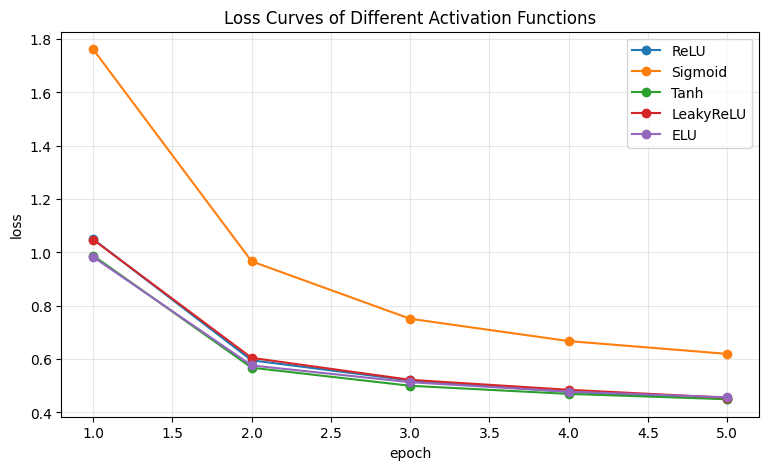

In [ ]:
plt.figure(figsize=(9, 5))
for name, hist in histories.items():
    plt.plot(hist['epoch'], hist['train_loss'], marker='o', label=name)

plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss Curves of Different Activation Functions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, hist in histories.items():
    print(f"{name:10s} | final train acc: {hist['train_acc'][-1]:.4f} | final test acc: {hist['test_acc'][-1]:.4f}")



### 7. 训练步骤 5：结果汇总（最终精度）


In [8]:
for name, hist in histories.items():
    print(f"{name:10s} | final train acc: {hist['train_acc'][-1]:.4f} | final test acc: {hist['test_acc'][-1]:.4f}")


ReLU       | final train acc: 0.8415 | final test acc: 0.8366
Sigmoid    | final train acc: 0.7730 | final test acc: 0.7727
Tanh       | final train acc: 0.8395 | final test acc: 0.8256
LeakyReLU  | final train acc: 0.8407 | final test acc: 0.8360
ELU        | final train acc: 0.8387 | final test acc: 0.7828
